In [1]:
import cv2
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union
import random
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid
from joblib import Parallel, delayed
import multiprocessing as mp
import matplotlib.pyplot as plt
from dataclasses import dataclass
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import copy
from sklearn.neighbors import NearestNeighbors
from skimage.metrics import structural_similarity

In [2]:
TRAIN_DIR = Path("train")
ORIGINAL_DIR = TRAIN_DIR / "original"
MASK_DIR = TRAIN_DIR / "mask"
DATA_DIR = Path("data")
BG_DIR = DATA_DIR / "background"
CELL_DIR = DATA_DIR / "cells"
TMP_DIR = DATA_DIR / "tmp"
PATCH_SIZE = 128
CONTEXT_BIN_SIZE = 32
MIN_CELL_AREA = 10 * 10

In [3]:
NOISE_PARAM_GRID_BIG = {
    "gaussian": {
        "mean": [0],
        "stddev": [5, 15, 25, 40, 100],
    },
    "uniform": {
        "low": [-10, -20, -40, -50, -60, -70],
        "high": [10, 20, 40, 50, 60, 70],
    },
}

DENOISE_PARAM_GRID_BIG = {
    "median": {
        "ksize": list(range(3, 15 + 1, 2)),
    },
    "gaussian": {
        "ksize": [(k, k) for k in range(3, 15 + 1, 2)],
        "sigmaX": [0, 1, 1.5],
    },
    "bilateral": {
        "d": [5, 9],
        "sigmaColor": [50, 75, 100, 150, 200],
        "sigmaSpace": [50, 75, 100, 150, 200],
    },
    "nlmeans": {
        "h": list(range(5, 20 + 1, 5)),
        "templateWindowSize": [5, 7],
        "searchWindowSize": [15, 21],
    },
}

NOISE_PARAM_GRID_MIN = {
    "gaussian": {
        "mean": [0],
        "stddev": [5, 15, 25, 40, 100],
    },
    "uniform": {
        "low": [-10, -20, -40, -50, -60, -70],
        "high": [20, 40, 50, 70],
    },
}


DENOISE_PARAM_GRID_MIN = {
    "median": {
        "ksize": [3, 5, 7, 9, 11, 15],
    },
    "gaussian": {
        "ksize": [(3, 3), (5, 5), (7, 7)],
        "sigmaX": [0, 1],
    },
    "bilateral": {
        "d": [5, 9],
        "sigmaColor": [50],
        "sigmaSpace": [50],
    },
    "nlmeans": {
        "h": [5, 10, 15, 20],
        "templateWindowSize": [5, 7],
        "searchWindowSize": [15, 21],
    },
}

NOISE_PARAM_GRID = NOISE_PARAM_GRID_MIN
DENOISE_PARAM_GRID = DENOISE_PARAM_GRID_MIN

In [4]:
def extract_patches(
    image: np.ndarray, mask: np.ndarray, patch_size: int = PATCH_SIZE
) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    h, w = image.shape[:2]
    patches = []
    masks = []

    for y in range(0, h - patch_size, patch_size // 2):
        for x in range(0, w - patch_size, patch_size // 2):
            patch_mask = ~mask[y : y + patch_size, x : x + patch_size]
            white_ratio = np.sum(patch_mask < 127) / (patch_size * patch_size)

            if white_ratio < 0.01:
                patch = image[y : y + patch_size, x : x + patch_size]
                patches.append(patch)
                masks.append(patch_mask)

    return patches, masks

@dataclass
class CellRecord:
    image: np.ndarray
    mask: np.ndarray
    context_key: Optional[Tuple[int, int, int]] = None


def quantize_color_key(
    color: Union[np.ndarray, Tuple[int, int, int]], bin_size: int = CONTEXT_BIN_SIZE
) -> Tuple[int, int, int]:
    color_arr = np.asarray(color, dtype=np.float32).clip(0, 255)
    return tuple((color_arr // bin_size).astype(int).tolist())

def extract_cells(
    image: np.ndarray, mask: np.ndarray, patch_size: int = PATCH_SIZE
) -> List[CellRecord]:
    h, w = image.shape[:2]
    cells: List[CellRecord] = []

    bg_pixels = image[mask == 0]
    if bg_pixels.size > 0:
        background_mean = bg_pixels.reshape(-1, 3).mean(axis=0)
    else:
        background_mean = image.reshape(-1, 3).mean(axis=0)
    context_key = quantize_color_key(background_mean)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < MIN_CELL_AREA:
            continue

        x, y, cw, ch = cv2.boundingRect(cnt)
        size = min(max(cw, ch), patch_size)

        cx, cy = x + cw // 2, y + ch // 2

        x1 = cx - size // 2
        y1 = cy - size // 2
        x2 = x1 + size
        y2 = y1 + size
        if x1 < 0 or y1 < 0 or x2 > w or y2 > h:
            continue  # maybe separate these cells on edge as a special case

        cell_img = image[y1:y2, x1:x2]
        cell_mask = mask[y1:y2, x1:x2]

        _, markers, stats, _ = cv2.connectedComponentsWithStats(cell_mask)
        dominated = stats[1:, cv2.CC_STAT_AREA].argmax() + 1
        cell_mask = copy.deepcopy(cell_mask)
        cell_mask[markers != dominated] = 0

        cells.append(
            CellRecord(
                image=cell_img,
                mask=cell_mask,
                context_key=context_key,
            )
        )

    return cells


def slice_dataset(sample_size: int = 100):
    BG_DIR.mkdir(exist_ok=True, parents=True)
    CELL_DIR.mkdir(exist_ok=True, parents=True)

    mask_files = sorted(MASK_DIR.iterdir())
    orig_files = sorted(ORIGINAL_DIR.iterdir())
    indices = random.sample(range(len(orig_files)), min(sample_size, len(orig_files)))

    bg_patches = []
    bg_masks = []
    cell_data: List[CellRecord] = []

    for i, idx in tqdm(enumerate(indices), "Slicing dataset", len(indices)):
        image = cv2.imread(orig_files[idx], cv2.IMREAD_COLOR_RGB)
        mask = cv2.imread(mask_files[idx], cv2.IMREAD_GRAYSCALE)

        patches, masks = extract_patches(image, mask)
        bg_patches.extend(patches)
        bg_masks.extend(masks)
        cell_data.extend(extract_cells(image, mask))
        # TODO:
        # 1. extract patches with multiple cells
        # 1. extract big patches (with multiple cells) as consequence

    print(f"Extracted {len(bg_patches)} background patches and {len(cell_data)} cells")

    bg_to_write = bg_patches[:5000]
    for i, patch in tqdm(
        enumerate(bg_to_write), "Writing BG patches", len(bg_to_write)
    ):
        cv2.imwrite(
            str(BG_DIR / f"bg_{i:05d}.png"), cv2.cvtColor(patch, cv2.COLOR_RGB2BGR)
        )

    cell_to_write = cell_data[:5000]
    for i, record in tqdm(
        enumerate(cell_to_write), "Writing Cell patches", len(cell_to_write)
    ):
        cell, cell_mask = record.image, record.mask
        cv2.imwrite(
            str(CELL_DIR / f"cell_{i:05d}.png"), cv2.cvtColor(cell, cv2.COLOR_RGB2BGR)
        )
        cv2.imwrite(str(CELL_DIR / f"cell_{i:05d}_mask.png"), cell_mask)

    return bg_patches, cell_data, bg_masks

In [5]:
def sample_from_histogram(hist: np.ndarray) -> Tuple[int, int, int]:
    flat = hist.flatten()
    idx = np.random.choice(len(flat), p=flat)
    coords = np.unravel_index(idx, hist.shape)
    b = coords[0] * 8 + np.random.randint(0, 8)
    g = coords[1] * 8 + np.random.randint(0, 8)
    r = coords[2] * 8 + np.random.randint(0, 8)
    return int(b), int(g), int(r)


def generate_background(
    target_size: Tuple[int, int],
    bg_patches: List[np.ndarray],
    bg_hist: np.ndarray,
    sampler: NearestNeighbors,
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = target_size
    bg = np.zeros((h, w, 3), dtype=np.uint8)

    base_color = sample_from_histogram(bg_hist)
    indices = sampler.kneighbors([base_color], return_distance=False)[0]
    random.shuffle(indices)
    patches = [bg_patches[i] for i in indices]
    c = 0

    for y in range(0, h, PATCH_SIZE):
        for x in range(0, w, PATCH_SIZE):
            y_end = min(y + PATCH_SIZE, h)
            x_end = min(x + PATCH_SIZE, w)

            if np.random.rand() < 0.3:
                color = base_color
            else:
                patch = patches[c]
                patch = cv2.resize(patch, (PATCH_SIZE, PATCH_SIZE))
                color = patch[: y_end - y, : x_end - x]
                c += 1

            bg[y:y_end, x:x_end] = color

    bg = cv2.GaussianBlur(bg, (5, 5), 0)
    return bg, base_color


def generate_synthetic_cell(
    target_size: int, color_hist: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    color = sample_from_histogram(color_hist)

    radius = np.random.randint(target_size // 4, target_size // 2)
    cell = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    cell[:] = 255
    mask = np.zeros((target_size, target_size), dtype=np.uint8)

    center = (target_size // 2, target_size // 2)
    cv2.circle(cell, center, radius, color, -1)
    cv2.circle(mask, center, radius, 255, -1)

    noise = np.random.randint(-20, 20, cell.shape, dtype=np.int16)
    cell = np.clip(cell.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return cell, mask

In [6]:
def add_noise(image: np.ndarray, noise_type: str = "gaussian", **params) -> np.ndarray:
    if noise_type == "gaussian":
        return cv2.add(image, cv2.randn(np.zeros_like(image), **params))
    elif noise_type == "uniform":
        return cv2.add(image, cv2.randu(np.zeros_like(image), **params))
    else:
        return image.copy()

In [7]:
class BloodCellDataset:
    def __init__(
        self,
        img_size: Tuple[int, int] = (256, 256),
    ):
        self.img_size = img_size

        self.noise_types_with_params = {
            "gaussian": list(ParameterGrid(NOISE_PARAM_GRID["gaussian"])),
            "uniform": list(ParameterGrid(NOISE_PARAM_GRID["uniform"])),
        }

        TMP_DIR.mkdir(exist_ok=True, parents=True)

        self.bg_patches = []
        self.bg_masks = []
        self.cell_data = []
        self.color_hist = None
        self.background_hist = None
        self.cells_by_context = {}
        self.color_hist_by_context = {}
        self.patch_count = 0
        self.nbrs = None
        self.avg_cells_per_patch = 1.0

    def fit(
        self,
        data: Tuple[List[np.ndarray], List[np.ndarray], List[CellRecord]],
        max_samples: int = 5000,
    ):
        bg_patches, bg_masks, cell_data = data
        if len(bg_patches) > max_samples:
            indices = random.sample(range(len(bg_patches)), max_samples)
            bg_patches = [bg_patches[i] for i in indices]
            bg_masks = [bg_masks[i] for i in indices]

        self.bg_patches = bg_patches
        self.bg_masks = bg_masks
        self.cell_data = [(record.image, record.mask) for record in cell_data]

        self.color_hist = BloodCellDataset._compute_color_hist(self.cell_data)
        self.background_hist = BloodCellDataset._compute_color_hist(
            list(zip(self.bg_patches, self.bg_masks))
        )
        self.cells_by_context = BloodCellDataset._build_context_index(cell_data)
        self.color_hist_by_context = BloodCellDataset._build_context_histograms(
            self.cells_by_context
        )

        mean_colors = np.mean(self.bg_patches, axis=(1, 2))

        patches_h = (self.img_size[0] + PATCH_SIZE - 1) // PATCH_SIZE
        patches_w = (self.img_size[1] + PATCH_SIZE - 1) // PATCH_SIZE

        self.patch_count = max(1, patches_h * patches_w)
        # * 2 for variety
        self.nbrs = NearestNeighbors(
            n_neighbors=self.patch_count * 2, algorithm="ball_tree"
        ).fit(
            mean_colors
        )  # will search for n_ closest to given color

        total_patch_pool = max(1, len(self.bg_patches) + len(self.cell_data))
        avg_cells_per_patch = len(self.cell_data) / total_patch_pool

        self.avg_num_cells = max(1.0, avg_cells_per_patch * self.patch_count)

    @staticmethod
    def _compute_color_hist(data: list, max_samples: int = 100) -> np.ndarray:
        hist = np.zeros((32, 32, 32), dtype=np.float32)
        if not data:
            hist += 1
            hist /= hist.sum()
            return hist

        sample_count = min(len(data), max(1, max_samples))
        if len(data) > sample_count:
            sampled_data = random.sample(data, sample_count)
        else:
            sampled_data = data

        for image, mask in sampled_data:
            h = cv2.calcHist(
                [image], [0, 1, 2], mask, [32, 32, 32], [0, 256, 0, 256, 0, 256]
            )
            h_sum = h.sum()
            if h_sum > 0:
                hist += h / h_sum
        if hist.sum() == 0:
            hist += 1

        hist /= hist.sum()

        return hist

    def __len__(self):
        raise NotImplementedError()
        return 0

    @staticmethod
    def _build_context_index(
        cell_data: List[CellRecord],
    ) -> Dict[Tuple[int, int, int], List[Tuple[np.ndarray, np.ndarray]]]:
        context_index = {}
        for record in cell_data:
            context_index.setdefault(record.context_key, []).append(
                (record.image, record.mask)
            )

        return context_index

    @staticmethod
    def _build_context_histograms(
        cells_by_context: Dict[
            Tuple[int, int, int], List[Tuple[np.ndarray, np.ndarray]]
        ],
    ) -> Dict[Tuple[int, int, int], np.ndarray]:
        return {
            context_key: BloodCellDataset._compute_color_hist(records)
            for context_key, records in cells_by_context.items()
        }

    def _get_real_cell_source(
        self, context_key: Tuple[int, int, int]
    ) -> List[Tuple[np.ndarray, np.ndarray]]:
        return self.cells_by_context.get(context_key, self.cell_data)

    def _get_synthetic_color_hist(
        self, context_key: Tuple[int, int, int]
    ) -> np.ndarray:
        return self.color_hist_by_context.get(context_key, self.color_hist)

    def _estimate_num_cells(self) -> int:
        return int(
            np.clip(np.random.poisson(self.avg_num_cells), 1, self.patch_count * 3)
        )

    def __getitem__(self, idx: int):
        np.random.seed(idx)
        random.seed(idx)

        bg, base_color = generate_background(
            self.img_size, self.bg_patches, self.background_hist, self.nbrs
        )
        context_key = quantize_color_key(base_color)

        cv2.imwrite(str(TMP_DIR / f"{idx:05d}_0_bg.png"), bg)

        num_cells = self._estimate_num_cells()

        for i in range(num_cells):
            # NOTE: key idea: not overfit future training but create representative dataset
            if self.cell_data and np.random.rand() < 0.7:
                source = self._get_real_cell_source(context_key)
                cell, cell_mask = source[np.random.randint(len(source))]
                cell = cv2.resize(cell, (PATCH_SIZE, PATCH_SIZE))
                cell_mask = cv2.resize(cell_mask, (PATCH_SIZE, PATCH_SIZE))
            else:
                synthetic_hist = self._get_synthetic_color_hist(context_key)
                cell, cell_mask = generate_synthetic_cell(PATCH_SIZE, synthetic_hist)

            cv2.imwrite(str(TMP_DIR / f"{idx:05d}_{i + 1}_cell_{i}.png"), cell)

            x = np.random.randint(PATCH_SIZE // 2, self.img_size[1] - PATCH_SIZE // 2)
            y = np.random.randint(PATCH_SIZE // 2, self.img_size[0] - PATCH_SIZE // 2)

            x1 = x - PATCH_SIZE // 2
            x2 = x + PATCH_SIZE // 2
            y1 = y - PATCH_SIZE // 2
            y2 = y + PATCH_SIZE // 2

            bg_roi = bg[y1:y2, x1:x2]

            result = bg.copy()
            src_roi = cell.copy()
            src_mask = cell_mask.copy()
            # src_roi[src_mask == 0] = base_color
            src_roi[src_mask == 0] = bg_roi[src_mask == 0]

            alpha = 0.7
            result[y1:y2, x1:x2] = cv2.addWeighted(src_roi, alpha, bg_roi, 1 - alpha, 0)

            bg = cv2.seamlessClone(cell, result, src_mask, (x, y), cv2.MIXED_CLONE)

        cv2.imwrite(str(TMP_DIR / f"{idx:05d}_{num_cells + 1}_bg_with_cells.png"), bg)

        noise_type = random.choice(["gaussian", "uniform"])
        noise_params = random.choice(self.noise_types_with_params[noise_type])

        gray_img = cv2.cvtColor(bg, cv2.COLOR_BGR2GRAY)
        noisy_img = add_noise(gray_img, noise_type, **noise_params)
        cv2.imwrite(str(TMP_DIR / f"{idx:05d}_{num_cells + 2}_noised.png"), noisy_img)

        return bg, gray_img, (noisy_img, noise_type, noise_params), num_cells


In [8]:
bg_patches, cell_data, bg_masks = slice_dataset(sample_size=100)

Slicing dataset: 100%|██████████| 100/100 [00:09<00:00, 10.33it/s]


Extracted 7573 background patches and 6398 cells


Writing Cell patches: 100%|██████████| 5000/5000 [00:03<00:00, 1282.97it/s]


In [9]:
dataset = BloodCellDataset(
    # img_size=(PATCH_SIZE * 9, PATCH_SIZE * 12),
    img_size=(PATCH_SIZE * 4, PATCH_SIZE * 5),
)
dataset.fit((bg_patches, bg_masks, cell_data))

### Research on Clone

In [10]:
bg, base_color = generate_background(
    dataset.img_size, dataset.bg_patches, dataset.background_hist, dataset.nbrs
)
bg = bg.copy()

In [11]:
cell, cell_mask = dataset.cell_data[1]
cell, cell_mask = cell.copy(), cell_mask.copy()
cell = cv2.resize(cell, (PATCH_SIZE, PATCH_SIZE))
cell_mask = cv2.resize(cell_mask, (PATCH_SIZE, PATCH_SIZE))

In [12]:
x = np.random.randint(PATCH_SIZE // 2, dataset.img_size[1] - PATCH_SIZE // 2)
y = np.random.randint(PATCH_SIZE // 2, dataset.img_size[0] - PATCH_SIZE // 2)

In [13]:
c1_centr = (PATCH_SIZE // 2, PATCH_SIZE // 2)
c1_r = PATCH_SIZE // 4
dx = c1_r + 10
poly = np.array(
    [
        [c1_centr[0] - dx, c1_centr[1] - dx],
        [c1_centr[0] + dx, c1_centr[1] - dx],
        [c1_centr[0] + dx, c1_centr[1] + dx],
        [c1_centr[0] - dx, c1_centr[1] + dx],
    ],
    np.int32,
)
src_mask = np.zeros_like(cell)
cv2.fillPoly(src_mask, [poly], (255, 255, 255))

bg_0 = cv2.seamlessClone(cell, bg, src_mask, (x, y), cv2.MIXED_CLONE)

In [14]:
src_mask = cell.copy()
src_mask[cell_mask == 0] = base_color
bg_1 = cv2.seamlessClone(cell, bg, src_mask.copy(), (x, y), cv2.MIXED_CLONE)

In [15]:
bg_2 = cv2.seamlessClone(src_mask, bg, cell_mask.copy(), (x, y), cv2.MIXED_CLONE)

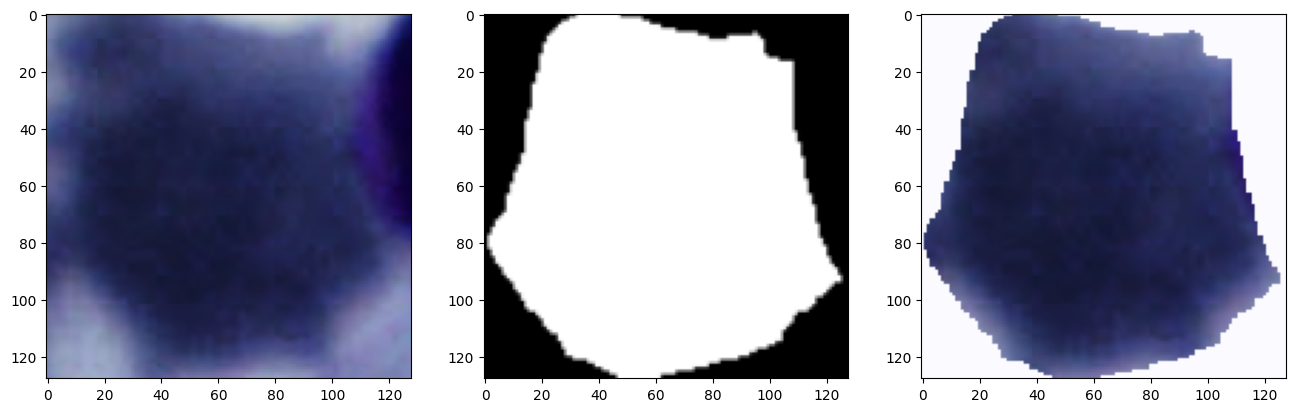

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(cell)
ax[1].imshow(cell_mask, cmap='gray')
ax[2].imshow(src_mask, cmap='gray')
plt.show()

In [17]:
result = bg.copy()

h, w = cell.shape[:2]

x1 = x - w // 2
x2 = x + w // 2
y1 = y - h // 2
y2 = y + h // 2

src_roi = cell.copy()
src_mask_ = cell_mask.copy()
src_roi[src_mask_ == 0] = base_color
bg_roi = bg[y1:y2, x1:x2]

alpha = 0.7
result[y1:y2, x1:x2] = cv2.addWeighted(src_roi, alpha, bg_roi, 1 - alpha, 0)

final = cv2.seamlessClone(cell, result, src_mask_, (x, y), cv2.NORMAL_CLONE)

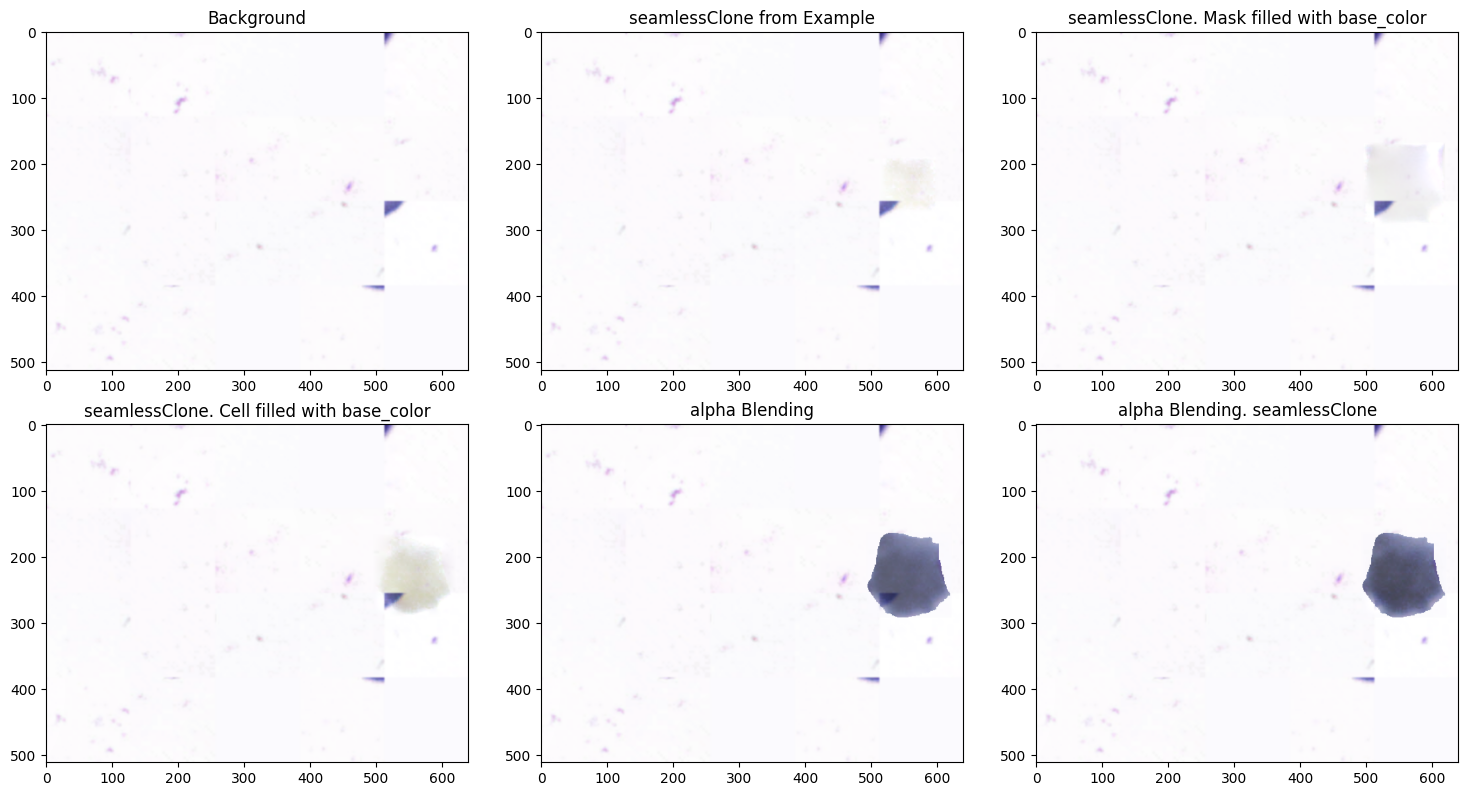

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax[0][0].imshow(bg)
ax[0][0].set_title('Background')
ax[0][1].imshow(bg_0)
ax[0][1].set_title('seamlessClone from Example')
ax[0][2].imshow(bg_1)
ax[0][2].set_title('seamlessClone. Mask filled with base_color')
ax[1][0].imshow(bg_2)
ax[1][0].set_title('seamlessClone. Cell filled with base_color')
ax[1][1].imshow(result)
ax[1][1].set_title('alpha Blending')
ax[1][2].imshow(final)
ax[1][2].set_title('alpha Blending. seamlessClone')

plt.tight_layout()
plt.show()

In [19]:
bg_ = bg.copy()

(128, 128, 3) (128, 128, 3)
(128, 128, 3) (128, 128, 3)
(128, 128, 3) (128, 128, 3)


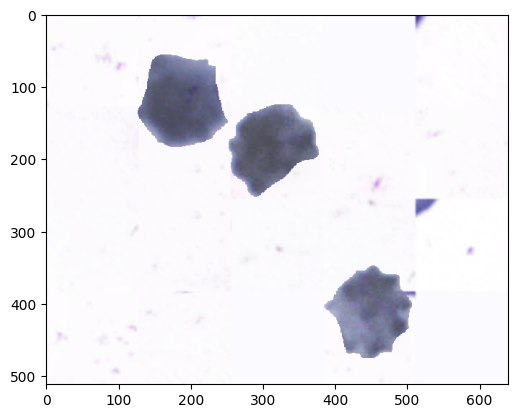

In [22]:
bg = bg_.copy()
np.random.seed(9)
idxs = [0, 1, 2]
for idx in idxs:
    cell, cell_mask = dataset.cell_data[idx]
    cell, cell_mask = cell.copy(), cell_mask.copy()
    cell = cv2.resize(cell, (PATCH_SIZE, PATCH_SIZE))
    cell_mask = cv2.resize(cell_mask, (PATCH_SIZE, PATCH_SIZE))

    x = np.random.randint(PATCH_SIZE // 2, bg.shape[1] - PATCH_SIZE // 2)
    y = np.random.randint(PATCH_SIZE // 2, bg.shape[0] - PATCH_SIZE // 2)

    x1 = x - PATCH_SIZE // 2
    x2 = x + PATCH_SIZE // 2
    y1 = y - PATCH_SIZE // 2
    y2 = y + PATCH_SIZE // 2

    bg_roi = bg[y1:y2, x1:x2]
    
    result = bg.copy()
    src_roi = cell.copy()
    src_mask = cell_mask.copy()
    src_roi[src_mask == 0] = bg_roi[src_mask == 0]

    print(bg_roi.shape, src_roi.shape)

    alpha = 0.7
    result[y1:y2, x1:x2] = cv2.addWeighted(src_roi, alpha, bg_roi, 1 - alpha, 0)

    bg = cv2.seamlessClone(cell, result, src_mask, (x, y), cv2.MIXED_CLONE)

plt.imshow(bg)

### Denoise Experiments

In [23]:
def _opencv_cuda_available() -> bool:
    if not hasattr(cv2, "cuda"):
        return False
    try:
        return cv2.cuda.getCudaEnabledDeviceCount() > 0
    except cv2.error:
        return False


def _opencv_opencl_available() -> bool:
    if not hasattr(cv2, "ocl"):
        return False
    try:
        if not cv2.ocl.haveOpenCL():
            return False
        cv2.ocl.setUseOpenCL(True)
        return bool(cv2.ocl.useOpenCL())
    except cv2.error:
        return False


def denoise_image(
    image: np.ndarray,
    method: str = "median",
    use_gpu: bool = False,
    accel_backend: str = "cpu",
    **params,
) -> np.ndarray:
    if image is None or image.size == 0:
        return image
    if (
        use_gpu
        and accel_backend == "cuda"
        and method in {"median", "gaussian", "bilateral"}
    ):
        try:
            gpu_image = cv2.cuda_GpuMat()
            gpu_image.upload(image)

            if method == "median":
                gpu_filter = cv2.cuda.createMedianFilter(
                    gpu_image.type(), params["ksize"]
                )
                denoised_gpu = gpu_filter.apply(gpu_image)
            elif method == "gaussian":
                gpu_filter = cv2.cuda.createGaussianFilter(
                    gpu_image.type(),
                    gpu_image.type(),
                    params["ksize"],
                    params.get("sigmaX", 0),
                )
                denoised_gpu = gpu_filter.apply(gpu_image)
            else:  # bilateral
                if hasattr(cv2.cuda, "bilateralFilter"):
                    denoised_gpu = cv2.cuda.bilateralFilter(
                        gpu_image,
                        params["d"],
                        params["sigmaColor"],
                        params["sigmaSpace"],
                    )
                else:
                    gpu_filter = cv2.cuda.createBilateralFilter(
                        gpu_image.type(),
                        params["d"],
                        params["sigmaColor"],
                        params["sigmaSpace"],
                    )
                    denoised_gpu = gpu_filter.apply(gpu_image)

            return denoised_gpu.download()
        except (cv2.error, KeyError, TypeError):
            pass

    if (
        use_gpu
        and accel_backend == "opencl"
        and method in {"median", "gaussian", "bilateral", "nlmeans"}
    ):
        try:
            umat = cv2.UMat(image)

            if method == "median":
                denoised = cv2.medianBlur(umat, **params)
            elif method == "gaussian":
                denoised = cv2.GaussianBlur(umat, **params)
            elif method == "bilateral":
                denoised = cv2.bilateralFilter(umat, **params)
            else:
                denoised = cv2.fastNlMeansDenoising(umat, **params)

            return denoised.get() if isinstance(denoised, cv2.UMat) else denoised
        except (cv2.error, KeyError, TypeError, AttributeError):
            pass
    if method == "median":
        result = cv2.medianBlur(image, **params)
    elif method == "gaussian":
        result = cv2.GaussianBlur(image, **params)
    elif method == "bilateral":
        result = cv2.bilateralFilter(image, **params)
    elif method == "nlmeans":
        result = cv2.fastNlMeansDenoising(image, **params)
    else:
        result = image

    return result


def calculate_metrics(
    original: np.ndarray,
    denoised: np.ndarray,
    use_gpu: bool = False,
    accel_backend: str = "cpu",
    ssim_obj=None,
) -> Tuple[float, float]:
    if use_gpu and accel_backend == "opencl":
        try:
            l2_norm = cv2.norm(original, denoised, cv2.NORM_L2)

            total_elements = original.size

            mse_gauss = (l2_norm**2) / total_elements
        except (cv2.error, AttributeError, TypeError):
            diff = original.astype(np.float32) - denoised.astype(np.float32)
            mse_gauss = float(np.mean(diff * diff))
    else:
        diff = original.astype(np.float32) - denoised.astype(np.float32)
        mse_gauss = float(np.mean(diff * diff))
    # ssim, _ = structural_similarity(original, denoised, full=True)
    # ssim = 0.0
    ssim = ssim_obj.compute(denoised)[0]
    return mse_gauss, ssim


In [24]:
def process_single_image(args):
    (
        (_, gray_img, _, _),
        noise_types_with_params,
        all_denoise_params,
        use_gpu,
        accel_backend,
    ) = args

    local_results = {}
    ssim_obj = cv2.quality.QualitySSIM_create(gray_img)

    for noise_type, noise_params_list in noise_types_with_params.items():
        for noise_params in noise_params_list:
            noise_key = f"{noise_type}_{noise_params}"
            local_results[noise_key] = {}

            noisy_img = add_noise(gray_img, noise_type, **noise_params)

            for method, params_list in all_denoise_params.items():
                for params in params_list:
                    param_key = f"{method}_{params}"

                    denoised = denoise_image(
                        noisy_img,
                        method,
                        use_gpu=use_gpu,
                        accel_backend=accel_backend,
                        **params,
                    )

                    mse, ssim = calculate_metrics(
                        gray_img,
                        denoised,
                        use_gpu=use_gpu,
                        accel_backend=accel_backend,
                        ssim_obj=ssim_obj,
                    )

                    local_results[noise_key][param_key] = {
                        "mse": mse,
                        "ssim": ssim,
                    }

    return local_results


def _write_denoising_results_report(
    aggregated_results: Dict[str, Dict[str, Dict[str, float]]],
    best_by_mse: Dict[str, Dict[str, float]],
    best_by_ssim: Dict[str, Dict[str, float]],
    output_path: Path,
) -> None:
    output_path.parent.mkdir(exist_ok=True, parents=True)

    lines = []
    lines.append("=" * 60)
    lines.append("DENOISING RESULTS")
    lines.append("=" * 60)

    for noise_key, method_metrics in aggregated_results.items():
        lines.append("")
        lines.append(f"--- {noise_key} ---")
        for method_key in sorted(method_metrics.keys()):
            metrics = method_metrics[method_key]
            lines.append(
                f"  {method_key}: MSE={metrics['mse']:.2f}, SSIM={metrics['ssim']:.4f}"
            )

    lines.append("")
    lines.append("=" * 60)
    lines.append("SUMMARY - Best methods by MSE:")
    lines.append("=" * 60)
    for noise_key, info in best_by_mse.items():
        lines.append(
            f"  {noise_key}: {info['method']} (MSE={info['mse']:.2f}, SSIM={info['ssim']:.4f})"
        )

    lines.append("")
    lines.append("=" * 60)
    lines.append("SUMMARY - Best methods by SSIM:")
    lines.append("=" * 60)
    for noise_key, info in best_by_ssim.items():
        lines.append(
            f"  {noise_key}: {info['method']} (MSE={info['mse']:.2f}, SSIM={info['ssim']:.4f})"
        )

    output_path.write_text("\n".join(lines), encoding="utf-8")


def run_denoising_experiment(
    dataset: BloodCellDataset, num_images: int = 100, use_gpu: bool = False
):
    results = {}
    cuda_available = _opencv_cuda_available()
    opencl_available = _opencv_opencl_available()

    accel_backend = "cpu"
    if use_gpu:
        if cuda_available:
            accel_backend = "cuda"
        elif opencl_available:
            accel_backend = "opencl"
        else:
            print(
                "No GPU acceleration backend available in OpenCV. Falling back to CPU."
            )

    effective_use_gpu = use_gpu and accel_backend in {"cuda", "opencl"}

    all_denoise_params = {
        method: list(ParameterGrid(DENOISE_PARAM_GRID[method]))
        for method in DENOISE_PARAM_GRID
    }
    noise_types_with_params = dataset.noise_types_with_params

    for noise_type, noise_params_list in noise_types_with_params.items():
        for noise_params in noise_params_list:
            key = f"{noise_type}_{noise_params}"
            results[key] = {}

            for method, params_list in all_denoise_params.items():
                results[key][method] = {
                    "mse": [],
                    "ssim": [],
                }

                for params in params_list:
                    results[key][f"{method}_{params}"] = {
                        "mse": [],
                        "ssim": [],
                    }
    print("Noise-Denoise configs:", len(results) * len(list(results.values())[0]))
    args_list = [
        (
            dataset[i],
            noise_types_with_params,
            all_denoise_params,
            effective_use_gpu,
            accel_backend,
        )
        for i in range(num_images)
    ]

    if accel_backend == "cuda":
        n_jobs = 1
        print("GPU mode enabled via CUDA for median/gaussian/bilateral filters.")
        print("Using n_jobs=1 to avoid multi-process CUDA contention.")
    else:
        n_jobs = min(mp.cpu_count(), 8) * 2

    print(f"Running denoising experiment with {n_jobs} parallel jobs...")

    # parallel_results = Parallel(n_jobs=n_jobs)(
    #     delayed(process_single_image)(args)
    #     for args in tqdm(args_list, desc="Processing images")
    # ) # TODO: make tasks larger (currenly it looks like spikes (on my machine))
    # parallel_results = (
    #     process_single_image(args) for args in tqdm(args_list, desc="Processing images")
    # )
    # with ProcessPoolExecutor(max_workers=n_jobs) as executor:
    with ThreadPoolExecutor(max_workers=n_jobs) as executor:
        parallel_results = list(
            tqdm(
                executor.map(process_single_image, args_list),
                total=len(args_list),
                desc="Processing images",
            )
        )

    for result in parallel_results:
        for noise_key, method_dict in result.items():
            for method_key, metrics in method_dict.items():
                results[noise_key][method_key]["mse"].append(metrics["mse"])
                results[noise_key][method_key]["ssim"].append(metrics["ssim"])

    best_by_mse = {}
    best_by_ssim = {}
    aggregated_results = {}

    for noise_key in results.keys():
        best_mse_value = float("inf")
        best_mse_method = None
        best_ssim_value = -float("inf")
        best_ssim_method = None
        aggregated_results[noise_key] = {}

        for method_key, metrics in results[noise_key].items():
            if metrics["mse"]:
                avg_mse = float(np.mean(metrics["mse"]))
                avg_ssim = float(np.mean(metrics["ssim"]))
                aggregated_results[noise_key][method_key] = {
                    "mse": avg_mse,
                    "ssim": avg_ssim,
                }

                if avg_mse < best_mse_value:
                    best_mse_value = avg_mse
                    best_mse_method = method_key

                if avg_ssim > best_ssim_value:
                    best_ssim_value = avg_ssim
                    best_ssim_method = method_key

        if best_mse_method is not None:
            best_mse_metrics = aggregated_results[noise_key][best_mse_method]
            best_by_mse[noise_key] = {
                "method": best_mse_method,
                "mse": best_mse_metrics["mse"],
                "ssim": best_mse_metrics["ssim"],
            }
        else:
            best_by_mse[noise_key] = {
                "method": None,
                "mse": float("nan"),
                "ssim": float("nan"),
            }

        if best_ssim_method is not None:
            best_ssim_metrics = aggregated_results[noise_key][best_ssim_method]
            best_by_ssim[noise_key] = {
                "method": best_ssim_method,
                "mse": best_ssim_metrics["mse"],
                "ssim": best_ssim_metrics["ssim"],
            }
        else:
            best_by_ssim[noise_key] = {
                "method": None,
                "mse": float("nan"),
                "ssim": float("nan"),
            }

    report_path = DATA_DIR / "denoising_results.txt"
    _write_denoising_results_report(
        aggregated_results,
        best_by_mse,
        best_by_ssim,
        report_path,
    )
    print(f"\nDetailed denoising results written to: {report_path}")

    print("\n" + "=" * 60)
    print("SUMMARY - Best methods by MSE:")
    print("=" * 60)
    for noise_key, info in best_by_mse.items():
        print(
            f"  {noise_key}: {info['method']} (MSE={info['mse']:.2f}, SSIM={info['ssim']:.4f})"
        )

    print("\n" + "=" * 60)
    print("SUMMARY - Best methods by SSIM:")
    print("=" * 60)
    for noise_key, info in best_by_ssim.items():
        print(
            f"  {noise_key}: {info['method']} (MSE={info['mse']:.2f}, SSIM={info['ssim']:.4f})"
        )

    return results


In [25]:
results = run_denoising_experiment(dataset, num_images=64, use_gpu=True)

Noise-Denoise configs: 986
Running denoising experiment with 16 parallel jobs...


Processing images: 100%|██████████| 64/64 [05:55<00:00,  5.55s/it] 



Detailed denoising results written to: data\denoising_results.txt

SUMMARY - Best methods by MSE:
  gaussian_{'mean': 0, 'stddev': 5}: nlmeans_{'h': 5, 'searchWindowSize': 15, 'templateWindowSize': 5} (MSE=4.98, SSIM=0.9757)
  gaussian_{'mean': 0, 'stddev': 15}: median_{'ksize': 5} (MSE=19.31, SSIM=0.9276)
  gaussian_{'mean': 0, 'stddev': 25}: median_{'ksize': 7} (MSE=33.13, SSIM=0.9129)
  gaussian_{'mean': 0, 'stddev': 40}: median_{'ksize': 7} (MSE=56.86, SSIM=0.8700)
  gaussian_{'mean': 0, 'stddev': 100}: median_{'ksize': 11} (MSE=166.29, SSIM=0.8086)
  uniform_{'high': 20, 'low': -10}: nlmeans_{'h': 10, 'searchWindowSize': 15, 'templateWindowSize': 5} (MSE=35.06, SSIM=0.9540)
  uniform_{'high': 20, 'low': -20}: median_{'ksize': 5} (MSE=17.11, SSIM=0.9315)
  uniform_{'high': 20, 'low': -40}: median_{'ksize': 3} (MSE=9.98, SSIM=0.9401)
  uniform_{'high': 20, 'low': -50}: nlmeans_{'h': 5, 'searchWindowSize': 21, 'templateWindowSize': 5} (MSE=8.07, SSIM=0.9699)
  uniform_{'high': 20, '